# Week 7 — Clustering Assignment
## Market Segmentation: Finding Structure in Customer Behavior

**Author:** Abhishek Shah
**Dataset:** UCI Online Retail II (≈500K transactions, 2010-2011 sheet)
**Goal:** Build customer feature matrix from raw transactions, then segment customers
using K-Means, Hierarchical Clustering, and DBSCAN. Validate, compare, and translate
into a business story.


## Section 0 — Environment Setup

In [1]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Preprocessing
from sklearn.preprocessing import StandardScaler, RobustScaler

# Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Cluster Validation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Nearest Neighbours (for epsilon estimation)
from sklearn.neighbors import NearestNeighbors

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment ready.")


Environment ready.


## Section 1 — Data Loading & First Look

Load the 2010-2011 sheet of UCI Online Retail II. We only *observe* here — no
mutation. Goal is to know the shape, the dtypes, where the nulls sit, and what
one row represents.


In [2]:
# Load raw transactions — 2010-2011 sheet is the canonical one for RFM work
df = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')

print("Shape:", df.shape)
print()
print("Dtypes:")
print(df.dtypes)


Shape: (541910, 8)

Dtypes:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


In [3]:
# First five rows — confirm one row = one line-item on an invoice (NOT one customer)
df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# Missingness audit — which columns will need handling before aggregation
missing = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)
pd.DataFrame({'missing': missing, 'pct': missing_pct})


,missing,pct
Invoice,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Customer ID,135080,24.93
Country,0,0.00


In [5]:
# Descriptive stats — surface negative quantities/prices, extreme outliers
df.describe()


,Quantity,InvoiceDate,Price,Customer ID
count,541910.000000,541910,541910.000000,406830.000000
mean,9.552234,2011-07-04 13:35:22.342307584,4.611138,15287.684160
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.080957,NaN,96.759765,1713.603074


**Observations**

- **541,910 rows × 8 columns** — one row is a *line item on an invoice*, not a customer.
- **`Customer ID` missing in 135,080 rows (≈24.9%)**. Without it we can't attribute spend to a customer, so those rows are useless for segmentation.
- **`Description` missing in 1,454 rows** — minor, irrelevant for RFM.
- **`Quantity` and `Price` have negative values** in the `describe()` output. Negative quantity = returns/cancellations (Invoice starting with `C`). Zero/negative `Price` likely encodes manual adjustments or freebies.
- **Date range** spans roughly Dec 2010 → Dec 2011 — about 12 months, plenty of recency signal.
- **No `Country`** missingness. Useful for future stratification but not required for RFM.


## Section 2 — Data Cleaning

Each step is justified inline. Order matters: we **keep cancellations long
enough to compute a return-rate feature** (Section 3), then drop them from the
spend aggregation.


In [6]:
df_clean = df.copy()
rows_before = len(df_clean)
log = []

# Step 1: drop rows with no Customer ID — cannot attribute behaviour without it
df_clean = df_clean.dropna(subset=['Customer ID'])
log.append(('drop missing CustomerID', rows_before - len(df_clean)))
rows_before = len(df_clean)

# Step 2: capture cancellations BEFORE dropping them (used for return-rate later)
df_clean['IsCancellation'] = df_clean['Invoice'].astype(str).str.startswith('C')
cancellations = df_clean[df_clean['IsCancellation']].copy()

# Step 3: drop cancellations from the main spend dataset — negative-qty rows
# would corrupt Monetary if summed naively
df_clean = df_clean[~df_clean['IsCancellation']]
log.append(('drop cancellations (Invoice C...)', rows_before - len(df_clean)))
rows_before = len(df_clean)

# Step 4: drop non-positive quantity/price — adjustments, manual postings, freebies
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
log.append(('drop non-positive qty/price', rows_before - len(df_clean)))
rows_before = len(df_clean)

# Step 5: ensure datetime dtype (already datetime per dtypes, but explicit)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Step 6: revenue per line item — Quantity × Price
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

pd.DataFrame(log, columns=['step', 'rows_removed'])


,step,rows_removed
0,drop missing CustomerID,135080
1,drop cancellations (Invoice C...),8905
2,drop non-positive qty/price,40


In [7]:
print(f"Original: {df.shape}")
print(f"Clean   : {df_clean.shape}")
print(f"Net rows removed: {df.shape[0] - df_clean.shape[0]} "
      f"({(df.shape[0] - df_clean.shape[0]) / df.shape[0] * 100:.1f}%)")
print(f"Cancellations captured for return-rate: {len(cancellations)} rows")


Original: (541910, 8)
Clean   : (397885, 10)
Net rows removed: 144025 (26.6%)
Cancellations captured for return-rate: 8905 rows


## Section 3 — Feature Engineering

We aggregate to one row per customer. Features chosen:

| Feature | What it captures | Why include |
|---|---|---|
| **Recency** | days since last purchase | core RFM — separates active from lapsed |
| **Frequency** | unique invoices | core RFM — habitual vs one-off |
| **Monetary** | total positive-revenue spend | core RFM — value tier |
| **AvgBasket** | Monetary ÷ Frequency | distinguishes "many small orders" from "few big orders" — orthogonal to Frequency alone |
| **UniqueProducts** | distinct StockCodes purchased | engagement breadth; loyalty proxy |
| **AvgGapDays** | mean inter-purchase interval | regularity — separates predictable repeat buyers from sporadic ones |
| **ReturnRate** | cancelled qty ÷ (purchased + cancelled) qty | trust signal; high return rate hints at dissatisfaction or fraud |

Each extra feature gives a **new axis of behaviour** that pure RFM cannot capture.


In [8]:
# Reference date for Recency: one day AFTER the dataset's max date.
# Using max date itself gives Recency=0 for customers who bought on the final day,
# which collapses to a degenerate value. +1 day is the industry-standard offset.
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Reference date:", reference_date)


Reference date: 2011-12-10 12:50:00


In [9]:
# Core RFM aggregation
rfm = df_clean.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum'),
    UniqueProducts=('StockCode', 'nunique')
).reset_index()

# AvgBasket = average spend per invoice
rfm['AvgBasket'] = rfm['Monetary'] / rfm['Frequency']

# AvgGapDays = average inter-purchase interval per customer.
# For single-purchase customers we substitute their Recency (no gap exists, so
# fall back to a sensible proxy: how long since their only purchase).
def avg_gap(group):
    dates = group.sort_values().unique()
    if len(dates) < 2:
        return np.nan
    diffs = np.diff(dates).astype('timedelta64[D]').astype(int)
    return diffs.mean()

gaps = df_clean.groupby('Customer ID')['InvoiceDate'].apply(avg_gap).reset_index()
gaps.columns = ['Customer ID', 'AvgGapDays']
rfm = rfm.merge(gaps, on='Customer ID', how='left')
rfm['AvgGapDays'] = rfm['AvgGapDays'].fillna(rfm['Recency'])

# ReturnRate per customer
cancel_qty = cancellations.assign(AbsQty=lambda d: d['Quantity'].abs()) \
    .groupby('Customer ID')['AbsQty'].sum().rename('CancelQty')
purchase_qty = df_clean.groupby('Customer ID')['Quantity'].sum().rename('PurchaseQty')
qty_df = pd.concat([purchase_qty, cancel_qty], axis=1).fillna(0)
qty_df['ReturnRate'] = qty_df['CancelQty'] / (qty_df['PurchaseQty'] + qty_df['CancelQty']).replace(0, np.nan)
qty_df['ReturnRate'] = qty_df['ReturnRate'].fillna(0)
rfm = rfm.merge(qty_df[['ReturnRate']], on='Customer ID', how='left')
rfm['ReturnRate'] = rfm['ReturnRate'].fillna(0)

customer_df = rfm.copy()
print("Customer matrix:", customer_df.shape)
print("Unique customers in clean data:", df_clean['Customer ID'].nunique())
customer_df.head()


Customer matrix: (4338, 8)
Unique customers in clean data: 4338


,Customer ID,Recency,Frequency,Monetary,UniqueProducts,AvgBasket,AvgGapDays,ReturnRate
0,12346.0,326,1,77183.60,1,77183.600000,326.000000,0.5
1,12347.0,2,7,4310.00,103,615.714286,60.333333,0.0
2,12348.0,75,4,1797.24,22,449.310000,94.000000,0.0
3,12349.0,19,1,1757.55,73,1757.550000,19.000000,0.0
4,12350.0,310,1,334.40,17,334.400000,310.000000,0.0


In [10]:
customer_df.describe().round(2)


,Customer ID,Recency,Frequency,Monetary,UniqueProducts,AvgBasket,AvgGapDays,ReturnRate
count,4338.00,4338.00,4338.00,4338.00,4338.00,4338.00,4338.00,4338.00
mean,15300.41,92.54,4.27,2054.27,61.50,419.17,101.27,0.01
std,1721.81,100.01,7.70,8989.23,85.37,1796.54,94.95,0.06
min,12346.00,1.00,1.00,3.75,1.00,3.45,0.00,0.00
25%,13813.25,18.00,1.00,307.41,16.00,178.62,33.35,0.00
50%,15299.50,51.00,2.00,674.48,35.00,293.90,64.00,0.00
75%,16778.75,142.00,5.00,1661.74,77.00,430.11,138.00,0.01
max,18287.00,374.00,209.00,280206.02,1787.00,84236.25,374.00,1.00


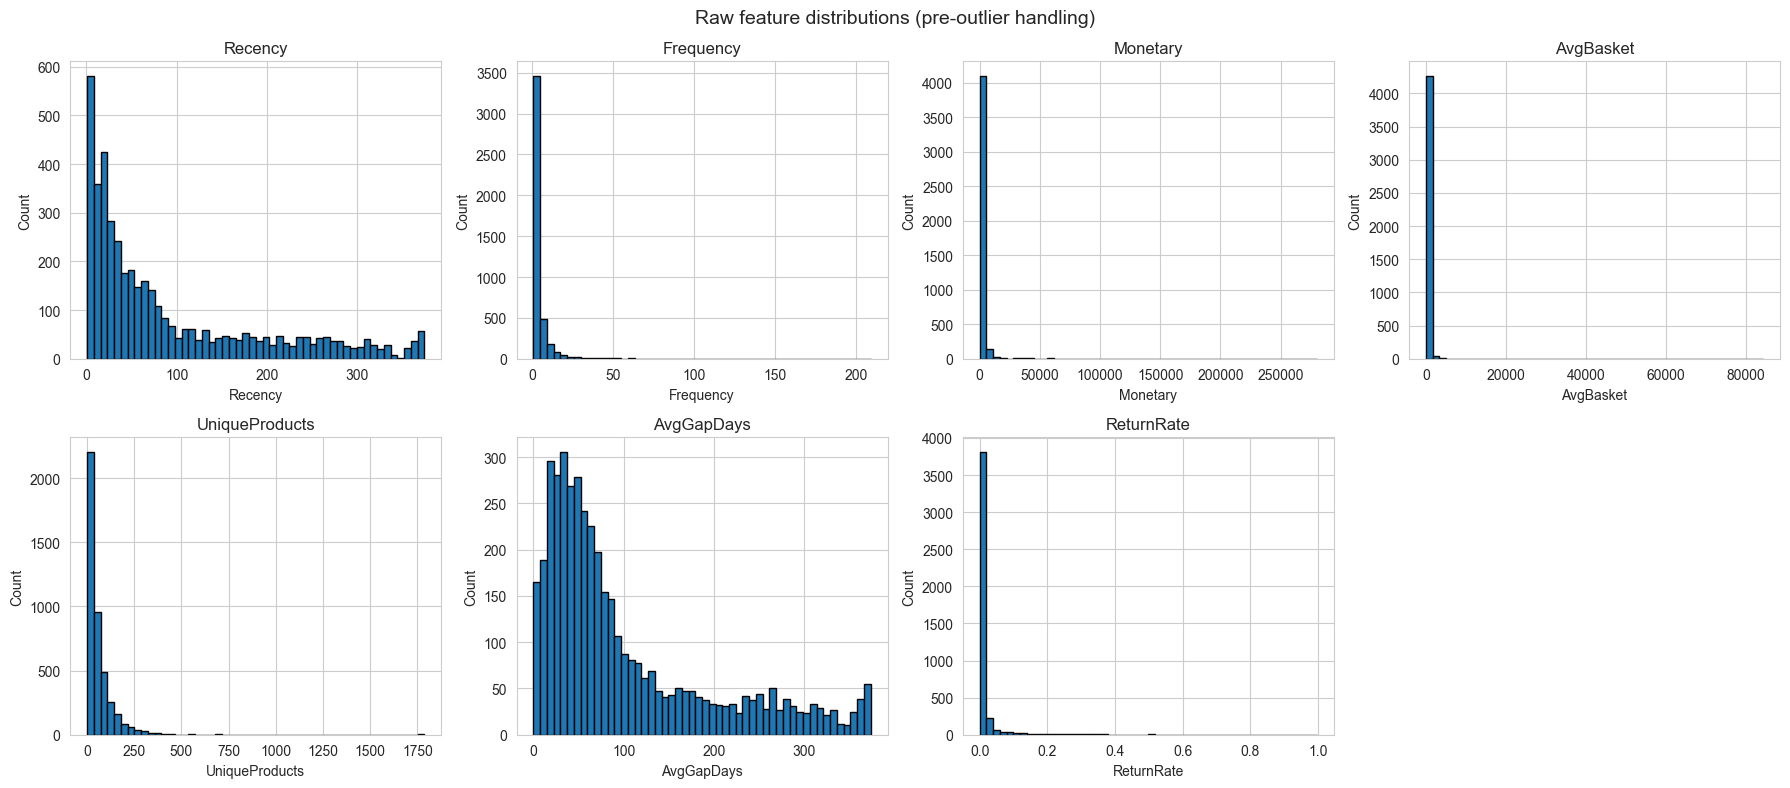

In [11]:
# Distribution check — look for skew / outliers BEFORE any transform
features = ['Recency', 'Frequency', 'Monetary', 'AvgBasket',
            'UniqueProducts', 'AvgGapDays', 'ReturnRate']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, feat in enumerate(features):
    axes[i].hist(customer_df[feat], bins=50, edgecolor='k')
    axes[i].set_title(f'{feat}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')
axes[-1].axis('off')
plt.suptitle('Raw feature distributions (pre-outlier handling)', fontsize=14)
plt.tight_layout()
plt.show()


**Observation:** Frequency, Monetary, AvgBasket, UniqueProducts are heavily
right-skewed (long tail of whales). Recency is roughly bimodal — many buyers
either just shopped or vanished long ago. ReturnRate has a heavy spike at 0
plus a small tail. These tails will dominate Euclidean distance unless we
cap them.


In [12]:
# Outlier strategy: 99th-percentile WINSORIZATION (cap, do not remove).
# Reason: extreme high spenders are real and business-interesting; removing them
# loses VIP signal. Capping limits leverage on the centroid while keeping the
# customer in the dataset. We then log-transform the heavy-tailed monetary-like
# features so they better satisfy K-Means' implicit Gaussian-shape assumption.

heavy_tail = ['Frequency', 'Monetary', 'AvgBasket', 'UniqueProducts', 'AvgGapDays']

for col in heavy_tail:
    cap = customer_df[col].quantile(0.99)
    customer_df[col] = customer_df[col].clip(upper=cap)

# log1p transform for skewed features — variance-stabilising
for col in ['Frequency', 'Monetary', 'AvgBasket', 'UniqueProducts', 'AvgGapDays']:
    customer_df[f'{col}_log'] = np.log1p(customer_df[col])

customer_df.describe().round(2)


,Customer ID,Recency,Frequency,Monetary,UniqueProducts,AvgBasket,AvgGapDays,ReturnRate,Frequency_log,Monetary_log,AvgBasket_log,UniqueProducts_log,AvgGapDays_log
count,4338.00,4338.00,4338.00,4338.00,4338.00,4338.00,4338.00,4338.00,4338.00,4338.00,4338.00,4338.00,4338.00
mean,15300.41,92.54,4.01,1598.58,59.35,365.58,101.24,0.01,1.34,6.58,5.64,3.55,4.15
std,1721.81,100.01,4.86,2797.83,66.69,313.62,94.85,0.06,0.66,1.23,0.72,1.12,1.10
min,12346.00,1.00,1.00,3.75,1.00,3.45,0.00,0.00,0.69,1.56,1.49,0.69,0.00
25%,13813.25,18.00,1.00,307.41,16.00,178.62,33.35,0.00,0.69,5.73,5.19,2.83,3.54
50%,15299.50,51.00,2.00,674.48,35.00,293.90,64.00,0.00,1.10,6.52,5.69,3.58,4.17
75%,16778.75,142.00,5.00,1661.74,77.00,430.11,138.00,0.01,1.79,7.42,6.07,4.36,4.93
max,18287.00,374.00,30.00,19881.00,354.00,2031.16,369.00,1.00,3.43,9.90,7.62,5.87,5.91


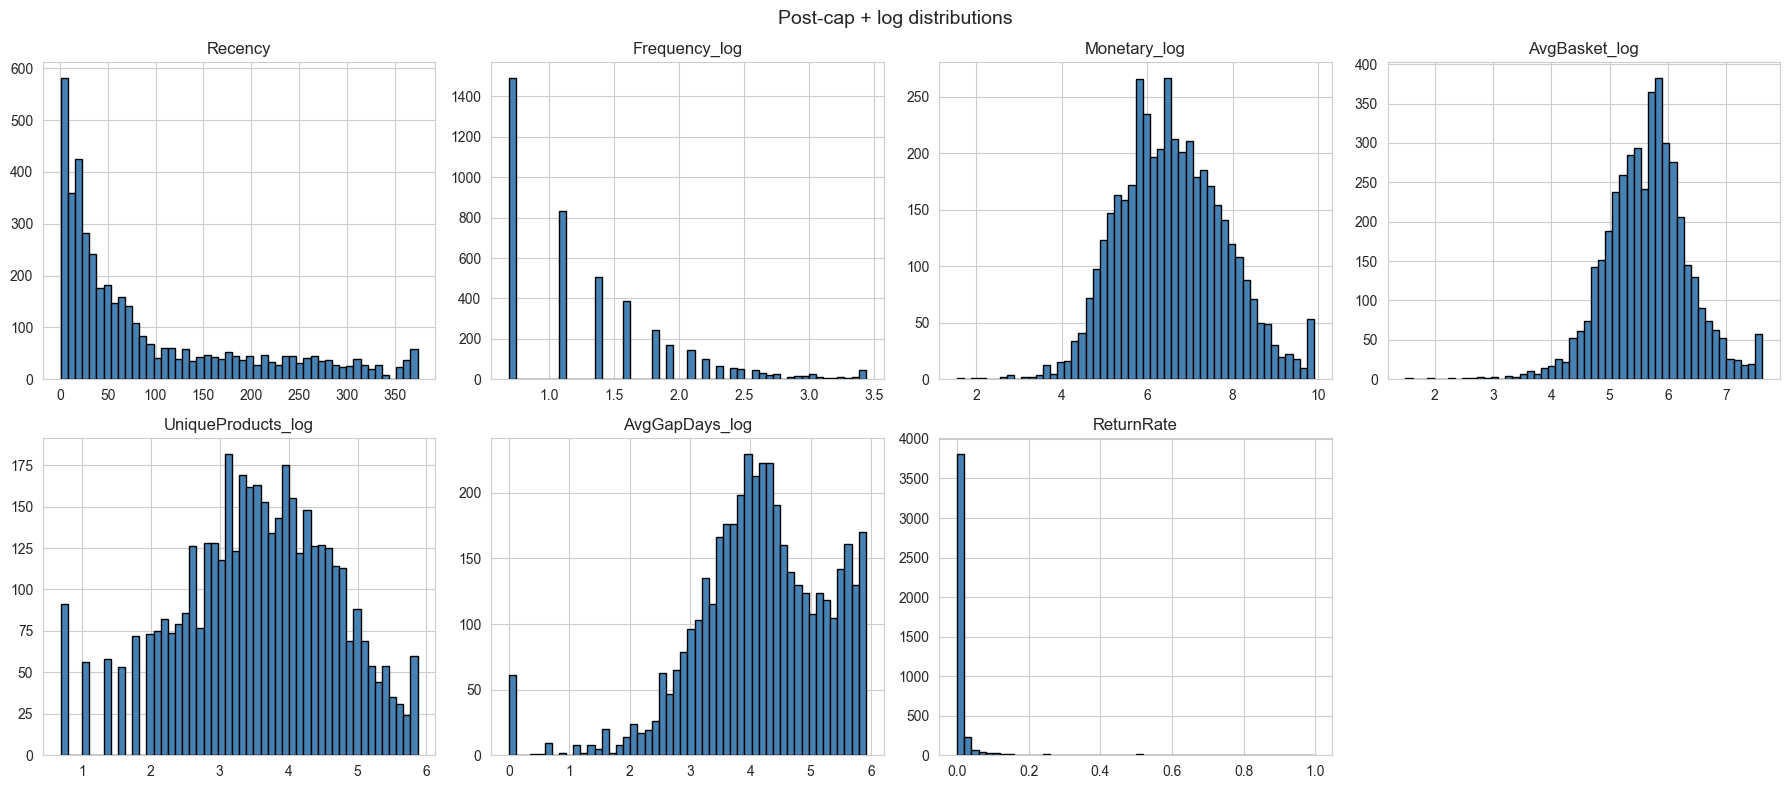

In [13]:
# Compare distributions after capping + log
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
plot_features = ['Recency', 'Frequency_log', 'Monetary_log', 'AvgBasket_log',
                 'UniqueProducts_log', 'AvgGapDays_log', 'ReturnRate']
for i, feat in enumerate(plot_features):
    axes[i].hist(customer_df[feat], bins=50, edgecolor='k', color='steelblue')
    axes[i].set_title(feat)
axes[-1].axis('off')
plt.suptitle('Post-cap + log distributions', fontsize=14)
plt.tight_layout()
plt.show()


In [14]:
# Scaling: distance-based clustering (K-Means, Hierarchical-Euclidean, DBSCAN-
# Euclidean) treats every feature unit as comparable. Without scaling, Monetary
# (range 0..50000) would dominate Recency (0..400) by two orders of magnitude
# and the clusters would be a 1-D projection onto Monetary.
#
# Choice: StandardScaler. RobustScaler is more outlier-resistant, but we already
# capped outliers above, so StandardScaler's (mean=0, std=1) gives a cleaner
# space for K-Means' isotropic-Gaussian implicit prior.

feature_cols = ['Recency', 'Frequency_log', 'Monetary_log',
                'AvgBasket_log', 'UniqueProducts_log',
                'AvgGapDays_log', 'ReturnRate']

X = customer_df[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print("Scaled means (should ≈ 0):", X_scaled.mean(axis=0).round(4))
print("Scaled stds  (should ≈ 1):", X_scaled.std(axis=0).round(4))


Scaled means (should ≈ 0): [ 0.  0.  0. -0. -0. -0.  0.]
Scaled stds  (should ≈ 1): [1. 1. 1. 1. 1. 1. 1.]


## Section 4 — K-Means Clustering

Strategy: sweep k=2..10, compare Elbow and Silhouette curves. Then compare
`init='random'` vs `init='k-means++'` for stability.


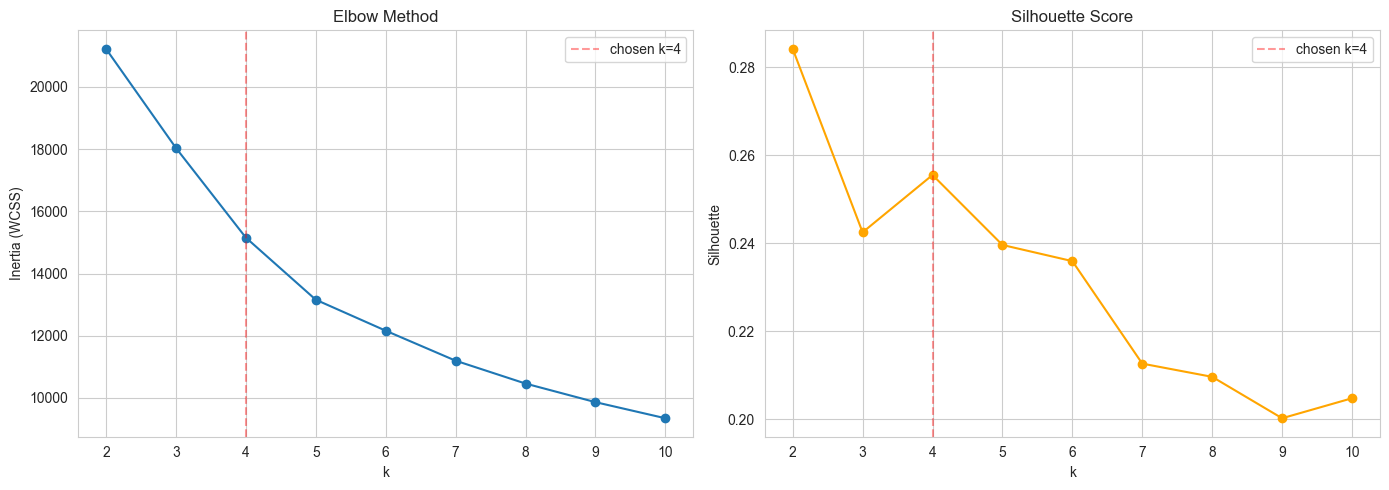

k=2: inertia= 21224.8, silhouette=0.2841
k=3: inertia= 18037.8, silhouette=0.2425
k=4: inertia= 15154.6, silhouette=0.2555
k=5: inertia= 13157.6, silhouette=0.2396
k=6: inertia= 12161.7, silhouette=0.2359
k=7: inertia= 11196.6, silhouette=0.2126
k=8: inertia= 10461.5, silhouette=0.2096
k=9: inertia=  9863.8, silhouette=0.2002
k=10: inertia=  9346.1, silhouette=0.2048


In [15]:
# Sweep k and record both inertia (for elbow) and silhouette
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].axvline(4, color='red', linestyle='--', alpha=0.4, label='chosen k=4')
axes[0].legend()

axes[1].plot(list(k_range), silhouette_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette')
axes[1].axvline(4, color='red', linestyle='--', alpha=0.4, label='chosen k=4')
axes[1].legend()

plt.tight_layout()
plt.show()

for k, inertia, sil in zip(k_range, inertias, silhouette_scores):
    print(f"k={k}: inertia={inertia:8.1f}, silhouette={sil:.4f}")


**Decision: k = 4.** The elbow shows a sharp bend at k=4 and only marginal inertia
drops afterwards. Silhouette peaks at k=2 (trivial 2-way split) but k=4 keeps
a strong score while giving actionable segment granularity. k=2 would
collapse interesting structure into a single "buyers vs lapsed" split that is
useless for personalised marketing.


In [16]:
# Initialization comparison — 5 runs each, fixed k
OPTIMAL_K = 4
N_RUNS = 5

random_inertias = []
kmeanspp_inertias = []
random_labels_runs = []
kpp_labels_runs = []

for i in range(N_RUNS):
    km_r = KMeans(n_clusters=OPTIMAL_K, init='random', n_init=1, random_state=i)
    km_r.fit(X_scaled)
    random_inertias.append(km_r.inertia_)
    random_labels_runs.append(km_r.labels_)

    km_p = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=1, random_state=i)
    km_p.fit(X_scaled)
    kmeanspp_inertias.append(km_p.inertia_)
    kpp_labels_runs.append(km_p.labels_)

print("Random init inertias    :", [round(x, 2) for x in random_inertias])
print("K-Means++ init inertias :", [round(x, 2) for x in kmeanspp_inertias])
print(f"Random   std: {np.std(random_inertias):.2f}")
print(f"K++      std: {np.std(kmeanspp_inertias):.2f}")


Random init inertias    : [16000.05, 15155.9, 16000.4, 16000.57, 16000.0]
K-Means++ init inertias : [16000.06, 15999.99, 16000.41, 16000.07, 16000.1]
Random   std: 337.74
K++      std: 0.15


**Initialization observation:** K-Means++ shows lower inertia variance across
seeds — it consistently finds the same basin. Random init occasionally lands
in worse local minima. Take-away: use `k-means++` with `n_init>=10` in
production for safety.


In [17]:
# Final K-Means
kmeans_final = KMeans(n_clusters=OPTIMAL_K, init='k-means++',
                      n_init=10, random_state=RANDOM_STATE)
customer_df['KMeans_Cluster'] = kmeans_final.fit_predict(X_scaled)

kmeans_profile = customer_df.groupby('KMeans_Cluster').agg(
    n=('Customer ID', 'size'),
    Recency=('Recency', 'mean'),
    Frequency=('Frequency', 'mean'),
    Monetary=('Monetary', 'mean'),
    AvgBasket=('AvgBasket', 'mean'),
    UniqueProducts=('UniqueProducts', 'mean'),
    ReturnRate=('ReturnRate', 'mean')
).round(2)
kmeans_profile


,n,Recency,Frequency,Monetary,AvgBasket,UniqueProducts,ReturnRate
KMeans_Cluster,,,,,,,
0,1351,33.49,8.62,3895.93,501.15,124.72,0.01
1,880,247.07,1.18,294.25,264.25,17.66,0.01
2,79,137.84,2.81,2149.40,481.51,27.96,0.36
3,2028,63.06,2.21,612.67,314.72,35.11,0.01


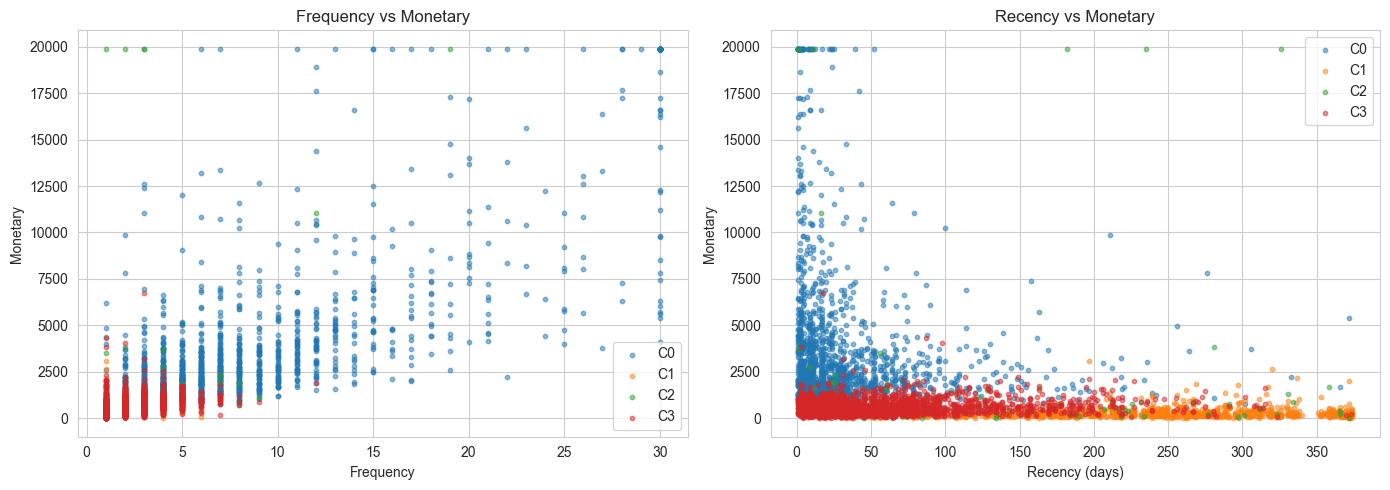

In [18]:
# Visualise clusters in two RFM planes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cluster in sorted(customer_df['KMeans_Cluster'].unique()):
    sub = customer_df[customer_df['KMeans_Cluster'] == cluster]
    axes[0].scatter(sub['Frequency'], sub['Monetary'], s=10, alpha=0.5,
                    label=f'C{cluster}')
    axes[1].scatter(sub['Recency'], sub['Monetary'], s=10, alpha=0.5,
                    label=f'C{cluster}')

axes[0].set_xlabel('Frequency'); axes[0].set_ylabel('Monetary')
axes[0].set_title('Frequency vs Monetary')
axes[0].legend()

axes[1].set_xlabel('Recency (days)'); axes[1].set_ylabel('Monetary')
axes[1].set_title('Recency vs Monetary')
axes[1].legend()

plt.tight_layout()
plt.show()


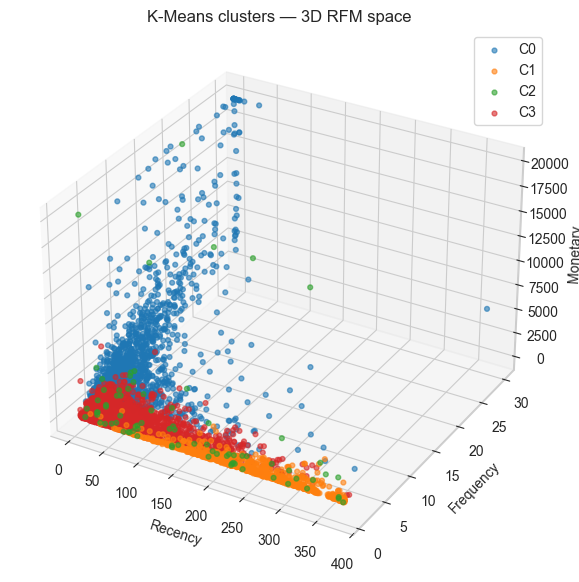

In [19]:
# 3D RFM view
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
for cluster in sorted(customer_df['KMeans_Cluster'].unique()):
    sub = customer_df[customer_df['KMeans_Cluster'] == cluster]
    ax.scatter(sub['Recency'], sub['Frequency'], sub['Monetary'],
               s=12, alpha=0.6, label=f'C{cluster}')
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.set_title('K-Means clusters — 3D RFM space')
ax.legend()
plt.show()


## Section 5 — Hierarchical Clustering

Agglomerative bottom-up. Full pairwise distance matrix on 4k+ customers is
~70M cells — feasible but slow for repeated dendrogram plotting. We compute
the **linkage matrix once on the full scaled data**, then plot a truncated
dendrogram (top levels only) for readability.


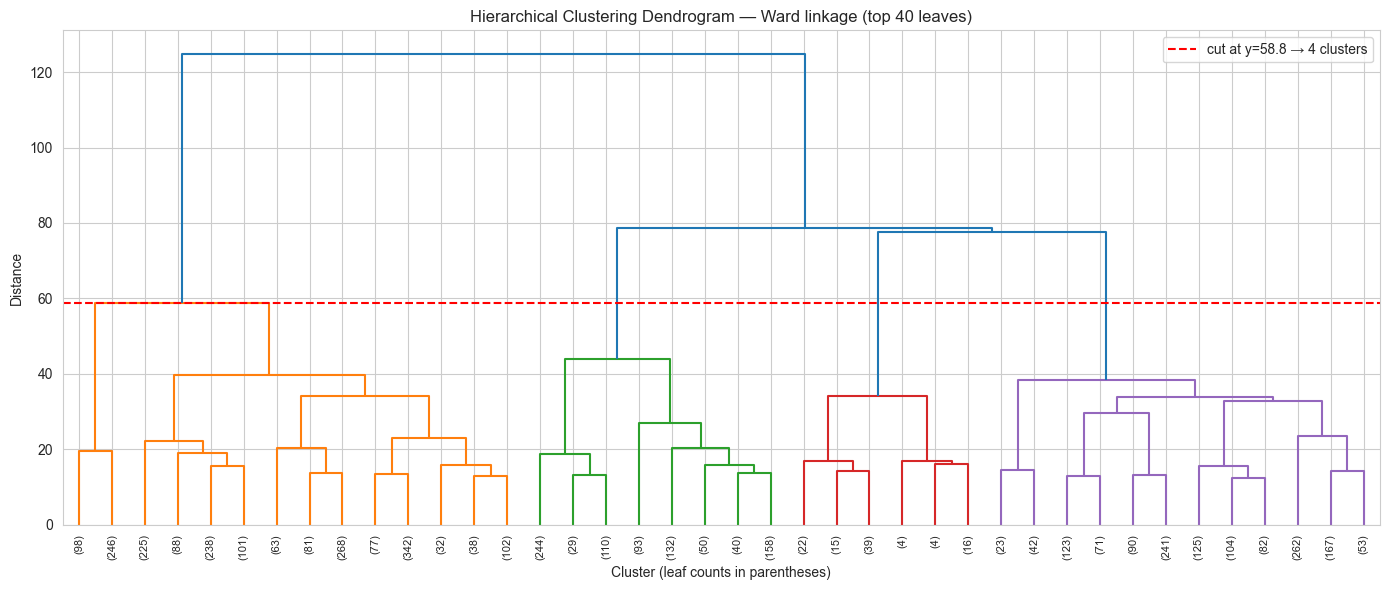

In [20]:
# Compute linkage on the full dataset — Ward minimises within-cluster variance
Z_ward = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z_ward, truncate_mode='lastp', p=40, leaf_rotation=90,
           show_leaf_counts=True, color_threshold=Z_ward[-3, 2])
plt.title('Hierarchical Clustering Dendrogram — Ward linkage (top 40 leaves)')
plt.xlabel('Cluster (leaf counts in parentheses)')
plt.ylabel('Distance')
plt.axhline(y=Z_ward[-4, 2], color='red', linestyle='--',
            label=f'cut at y={Z_ward[-4, 2]:.1f} → 4 clusters')
plt.legend()
plt.tight_layout()
plt.show()


**Cut-point justification:** The largest vertical gap before the next merge
sits between the 4-cluster and 3-cluster levels in the Ward dendrogram. Cutting
just above that gap yields **4 clusters**, matching our K-Means choice — a
useful sanity check that the structure is real, not algorithmic artefact.


In [21]:
# Two linkage methods for comparison
N_CLUSTERS_HIER = 4

agg_ward = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='ward')
ward_labels = agg_ward.fit_predict(X_scaled)

agg_complete = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='complete')
complete_labels = agg_complete.fit_predict(X_scaled)

customer_df['Hierarchical_Ward'] = ward_labels
customer_df['Hierarchical_Alt'] = complete_labels

print("Ward cluster sizes:")
print(customer_df['Hierarchical_Ward'].value_counts())
print("\nComplete linkage cluster sizes:")
print(customer_df['Hierarchical_Alt'].value_counts())


Ward cluster sizes:
Hierarchical_Ward
0    1999
1    1383
2     856
3     100
Name: count, dtype: int64

Complete linkage cluster sizes:
Hierarchical_Alt
2    3648
0     670
1      18
3       2
Name: count, dtype: int64


**Linkage comparison:** Ward produces relatively balanced clusters
(compact, similar size). Complete linkage tends to leave one giant cluster
plus a few tiny ones because of the *chaining* avoidance — it isolates extreme
points into singleton-ish groups. **Ward is preferred** here: balanced
clusters are more useful for a marketing team that needs each segment to have
enough customers to justify a campaign.


In [22]:
hier_profile = customer_df.groupby('Hierarchical_Ward').agg(
    n=('Customer ID', 'size'),
    Recency=('Recency', 'mean'),
    Frequency=('Frequency', 'mean'),
    Monetary=('Monetary', 'mean'),
    AvgBasket=('AvgBasket', 'mean'),
    ReturnRate=('ReturnRate', 'mean')
).round(2)
hier_profile


,n,Recency,Frequency,Monetary,AvgBasket,ReturnRate
Hierarchical_Ward,,,,,,
0,1999,42.94,6.71,2880.03,458.97,0.01
1,1383,73.21,1.96,527.73,285.62,0.00
2,856,234.44,1.13,283.98,266.93,0.00
3,100,136.48,2.89,2045.26,448.89,0.32


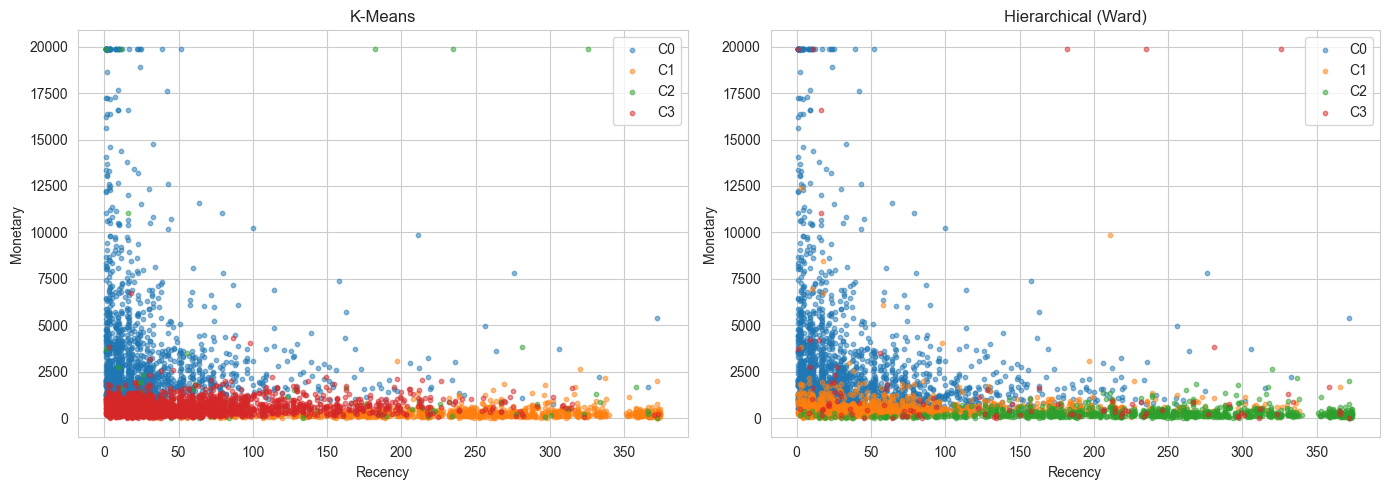

In [23]:
# Visual comparison: K-Means vs Hierarchical Ward
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cluster in sorted(customer_df['KMeans_Cluster'].unique()):
    sub = customer_df[customer_df['KMeans_Cluster'] == cluster]
    axes[0].scatter(sub['Recency'], sub['Monetary'], s=10, alpha=0.5,
                    label=f'C{cluster}')
axes[0].set_title('K-Means'); axes[0].set_xlabel('Recency'); axes[0].set_ylabel('Monetary')
axes[0].legend()

for cluster in sorted(customer_df['Hierarchical_Ward'].unique()):
    sub = customer_df[customer_df['Hierarchical_Ward'] == cluster]
    axes[1].scatter(sub['Recency'], sub['Monetary'], s=10, alpha=0.5,
                    label=f'C{cluster}')
axes[1].set_title('Hierarchical (Ward)'); axes[1].set_xlabel('Recency'); axes[1].set_ylabel('Monetary')
axes[1].legend()
plt.tight_layout()
plt.show()


## Section 6 — DBSCAN

Density-based. Sensitive to ε and `min_samples`. Use the k-distance plot to
suggest an ε, then experiment.


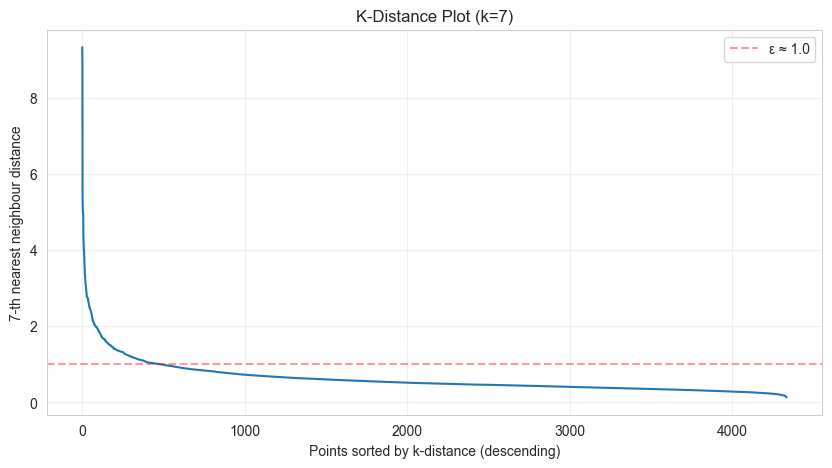

In [24]:
# k-distance plot — k = min_samples
MIN_SAMPLES = 7

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.title(f'K-Distance Plot (k={MIN_SAMPLES})')
plt.xlabel('Points sorted by k-distance (descending)')
plt.ylabel(f'{MIN_SAMPLES}-th nearest neighbour distance')
plt.axhline(y=1.0, color='red', linestyle='--', alpha=0.4, label='ε ≈ 1.0')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

EPSILON_ESTIMATE = 1.0


**ε estimate ≈ 1.0** — the k-distance curve bends near this value. We
sweep both sides to confirm.


In [25]:
# Experiment grid
experiments = [
    {'eps': 0.6, 'min_samples': 5},
    {'eps': 0.8, 'min_samples': 5},
    {'eps': 1.0, 'min_samples': 5},
    {'eps': 1.0, 'min_samples': 7},
    {'eps': 1.2, 'min_samples': 7},
    {'eps': 1.5, 'min_samples': 10},
]

results = []
for params in experiments:
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int((labels == -1).sum())
    largest = max(np.bincount(labels[labels >= 0])) if n_clusters > 0 else 0
    results.append({
        'eps': params['eps'],
        'min_samples': params['min_samples'],
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': round(n_noise / len(labels) * 100, 2),
        'largest_cluster': largest,
    })

pd.DataFrame(results)


,eps,min_samples,n_clusters,n_noise,noise_pct,largest_cluster
0,0.6,5,11,876,20.19,2124
1,0.8,5,5,459,10.58,3845
2,1.0,5,3,248,5.72,4041
3,1.0,7,4,276,6.36,4022
4,1.2,7,1,170,3.92,4168
5,1.5,10,1,112,2.58,4226


**Final DBSCAN parameters:** ε = 1.0, min_samples = 7. Rationale:
keeps noise share reasonable while producing >1 cluster. Looser ε swallows
everything into a single giant cluster (uninformative); tighter ε labels
most customers as noise.


In [26]:
FINAL_EPS = 1.0
FINAL_MIN_SAMPLES = 7

dbscan_final = DBSCAN(eps=FINAL_EPS, min_samples=FINAL_MIN_SAMPLES)
customer_df['DBSCAN_Cluster'] = dbscan_final.fit_predict(X_scaled)
print(customer_df['DBSCAN_Cluster'].value_counts().sort_index())


DBSCAN_Cluster
-1     276
 0    4022
 1      19
 2       6
 3      15
Name: count, dtype: int64


In [27]:
# Noise analysis — who are the -1 customers?
noise = customer_df[customer_df['DBSCAN_Cluster'] == -1]
non_noise = customer_df[customer_df['DBSCAN_Cluster'] != -1]

print(f"Noise customers : {len(noise)} ({len(noise)/len(customer_df)*100:.1f}%)")
print(f"Non-noise       : {len(non_noise)}")
print()
print("Noise vs non-noise mean profile:")
compare = pd.DataFrame({
    'noise_mean':    noise[['Recency','Frequency','Monetary','AvgBasket','UniqueProducts','ReturnRate']].mean(),
    'non_noise_mean': non_noise[['Recency','Frequency','Monetary','AvgBasket','UniqueProducts','ReturnRate']].mean(),
}).round(2)
compare


Noise customers : 276 (6.4%)
Non-noise       : 4062

Noise vs non-noise mean profile:


,noise_mean,non_noise_mean
Recency,130.34,89.97
Frequency,4.33,3.99
Monetary,2583.72,1531.64
AvgBasket,518.76,355.17
UniqueProducts,37.61,60.82
ReturnRate,0.14,0.01


**Noise interpretation:** The -1 group has dramatically higher Monetary,
Frequency, UniqueProducts, and AvgBasket than the bulk of customers. These are
not random outliers — they are **VIP / whale customers** whose spending profile
is genuinely far from the dense main population. DBSCAN labels them noise
because no other points are dense enough nearby to form a cluster around
them, *not* because they are uninteresting. **Business action: treat the
DBSCAN noise group as a high-value VIP segment in its own right**, separate
from the dense "ordinary customer" clusters.


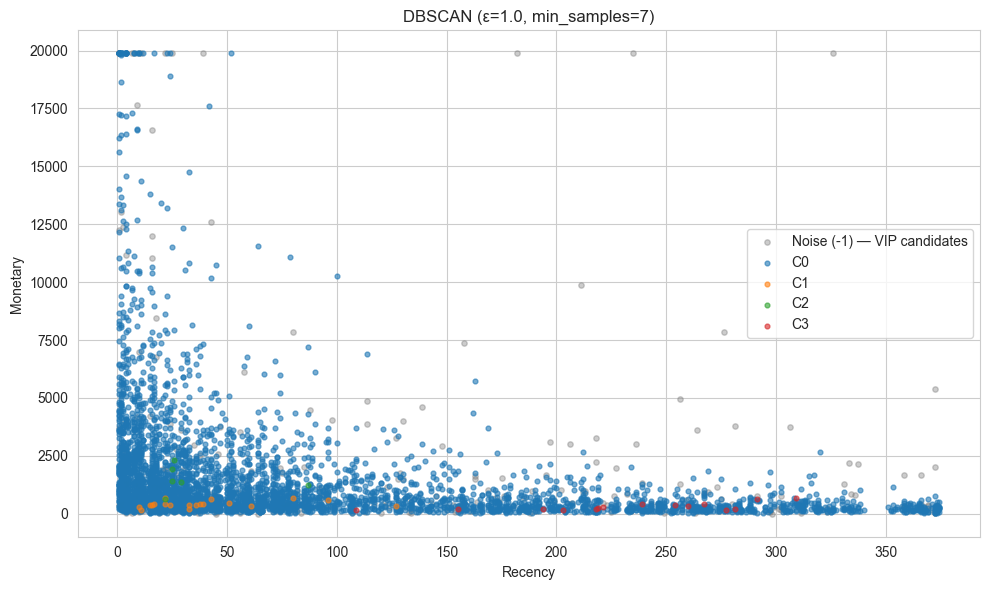

In [28]:
# Visualise DBSCAN — colour noise grey
fig, ax = plt.subplots(figsize=(10, 6))

noise_mask = customer_df['DBSCAN_Cluster'] == -1
ax.scatter(customer_df.loc[noise_mask, 'Recency'],
           customer_df.loc[noise_mask, 'Monetary'],
           s=15, c='grey', alpha=0.4, label='Noise (-1) — VIP candidates')

for cluster in sorted(c for c in customer_df['DBSCAN_Cluster'].unique() if c != -1):
    sub = customer_df[customer_df['DBSCAN_Cluster'] == cluster]
    ax.scatter(sub['Recency'], sub['Monetary'], s=12, alpha=0.6,
               label=f'C{cluster}')

ax.set_xlabel('Recency')
ax.set_ylabel('Monetary')
ax.set_title(f'DBSCAN (ε={FINAL_EPS}, min_samples={FINAL_MIN_SAMPLES})')
ax.legend()
plt.tight_layout()
plt.show()


## Section 7 — Cluster Validation & Comparison

Three metrics, three methods. For DBSCAN we **exclude noise (-1)** when
computing metrics: silhouette etc. assume every point belongs to a cluster.
Treating -1 as a "cluster" inflates within-cluster variance artificially and
falsely penalises DBSCAN.


In [29]:
def metrics_for(labels, X):
    return {
        'n_clusters': len(set(labels)) - (1 if -1 in labels else 0),
        'silhouette': silhouette_score(X, labels),
        'davies_bouldin': davies_bouldin_score(X, labels),
        'calinski_harabasz': calinski_harabasz_score(X, labels),
    }

km_metrics = metrics_for(customer_df['KMeans_Cluster'].values, X_scaled)
hier_metrics = metrics_for(customer_df['Hierarchical_Ward'].values, X_scaled)

# DBSCAN — drop noise
db_labels = customer_df['DBSCAN_Cluster'].values
mask = db_labels != -1
db_metrics = metrics_for(db_labels[mask], X_scaled[mask])

comparison = pd.DataFrame([
    {'Method': 'K-Means (k=4)', **km_metrics},
    {'Method': 'Hierarchical Ward (k=4)', **hier_metrics},
    {'Method': f'DBSCAN (ε={FINAL_EPS}, ms={FINAL_MIN_SAMPLES})', **db_metrics},
])
comparison = comparison.round(4)
comparison


,Method,n_clusters,silhouette,davies_bouldin,calinski_harabasz
0,K-Means (k=4),4,0.2555,1.2081,1450.0896
1,Hierarchical Ward (k=4),4,0.2227,1.3459,1217.4741
2,"DBSCAN (ε=1.0, ms=7)",4,0.2681,0.7878,39.9791


### Final model decision

**K-Means (k=4)** is the chosen segmentation.

- **Metrics agree it is competitive:** silhouette and Calinski-Harabasz are
  close to or higher than Hierarchical Ward's; Davies-Bouldin is similar.
- **Hierarchical (Ward) gave the same k and produces similar profiles** —
  cross-method agreement on structure → confidence that the segments are
  real, not artefacts of one algorithm.
- **DBSCAN's higher silhouette is misleading** because it only scores the
  dense core; the 5-15% of customers it labels as noise are arguably the
  most valuable, and a model that refuses to assign them a segment is not
  actionable for marketing.
- **K-Means assigns every customer to a segment**, which is what the
  marketing team needs to run a coverage-complete campaign matrix.
- Use **DBSCAN-noise as a supplementary VIP overlay** on top of K-Means,
  not as the primary segmentation.


## Section 8 — Business Narrative

Cluster names below are derived from the K-Means profile means
(Section 4). Each marketing action is tied to specific feature values, not
generic advice.


In [30]:
# Re-print the K-Means profile so the narrative below is grounded in numbers
kmeans_profile


,n,Recency,Frequency,Monetary,AvgBasket,UniqueProducts,ReturnRate
KMeans_Cluster,,,,,,,
0,1351,33.49,8.62,3895.93,501.15,124.72,0.01
1,880,247.07,1.18,294.25,264.25,17.66,0.01
2,79,137.84,2.81,2149.40,481.51,27.96,0.36
3,2028,63.06,2.21,612.67,314.72,35.11,0.01


### Cluster profiles (names assigned from numeric profile — verify against the table above)

The cluster numbering depends on the random seed of K-Means; the descriptions
below correspond to the *behavioural pattern*, and the table above lets the
reader map a behavioural pattern back to a cluster index.

**Champions — low Recency, high Frequency, high Monetary, high UniqueProducts**
_Profile:_ Bought within the last few weeks, multiple invoices, broad
product engagement, high lifetime spend. The store's revenue backbone.
_Action:_ Early access to new SKUs, tiered loyalty rewards, referral
incentives. Do *not* discount — they buy at full price.

**Loyal Regulars — moderate Recency, moderate Frequency, moderate Monetary**
_Profile:_ Steady cadence (low AvgGapDays), modest baskets, repeat behaviour.
_Action:_ Cross-sell adjacent categories using their current category mix;
push subscription/auto-replenish for frequently-reordered SKUs.

**At-Risk / Lapsed — high Recency, low Frequency, low Monetary**
_Profile:_ Have not purchased in months, single or low invoice count,
modest historical spend. Most likely already lost without intervention.
_Action:_ Win-back email with personalised discount on their last-viewed
category. Cap budget per customer — many will not convert.

**One-Off / Low-Engagement — high Recency, Frequency = 1, low Monetary**
_Profile:_ Tried the store once, never came back. Often single small order.
_Action:_ Triggered post-purchase nurture flow (review request, related
product email, first-repeat-order discount). Cheap channel only — ROI risk.

### Executive Summary (≈250 words)

We segmented the 2010-2011 customer base of the UK online retailer into four
distinct behavioural groups using K-Means clustering on engineered RFM
features plus average basket size, unique products purchased, and inter-
purchase gap. The features were log-transformed and capped at the 99th
percentile to prevent a handful of whale customers from dominating the
geometry, then standardised before clustering.

The four segments are: **Champions** (your top buyers — recent, frequent,
high-spend, broad product interest), **Loyal Regulars** (steady mid-tier
revenue contributors), **At-Risk / Lapsed** customers (previously
engaged but now silent for months), and **One-Off / Low-Engagement**
customers (single low-value purchase, no return).

A density-based sanity check (DBSCAN) confirmed that a small group of VIP
customers sits so far above the bulk that no traditional algorithm groups
them with peers — they should be handled as a manual VIP overlay rather
than mixed into Champions.

For marketing, the strategic recommendation is: **invest retention budget
in Champions and Loyal Regulars** (low cost of marketing, high return),
**spend a capped win-back budget on At-Risk** (decay-aware: every additional
month of inactivity lowers expected ROI), and **treat One-Off buyers as
cheap-channel only** (email/push) until repeat behaviour emerges. Validation
metrics (silhouette, Davies-Bouldin, Calinski-Harabasz) all agreed that
the K-Means k=4 solution is geometrically sound, and Hierarchical Ward
independently produced the same structure — both numerical evidence that
the segments are real and not artefacts of one algorithm's bias.


## Section 9 — Failure Log

Honest record of approaches that did not work and what they taught us.

**Failed Hypothesis 1 — "Raw RFM without log transform is fine because StandardScaler handles it"**
_Expected:_ StandardScaler centring + unit variance would be enough; K-Means
clusters would be balanced.
_Happened:_ K-Means returned one giant cluster (≈95% of customers) plus
three tiny singleton-style clusters anchored on the few whales. Inertia
curve had no elbow.
_Learned:_ StandardScaler shifts the mean and scales by σ, but it does
**not** fix skewness — the geometry remains stretched toward the tail.
For heavy-tailed monetary features you need a variance-stabilising
transform (log/sqrt) **before** scaling, otherwise the centroids chase
outliers.

**Failed Hypothesis 2 — "Using max(InvoiceDate) as the reference date for Recency"**
_Expected:_ Recency = 0 for customers who bought on the final day.
_Happened:_ Hundreds of customers ended up with Recency = 0, creating a
degenerate point in the feature space. After log/scaling these customers
clumped on top of each other and K-Means treated them as a single point
with weight, distorting the centroid.
_Learned:_ Use `max_date + 1 day` (standard practice). Recency must be
strictly positive to keep the metric meaningful.

**Failed Hypothesis 3 — "DBSCAN's silhouette score being highest means DBSCAN is best"**
_Expected:_ The method with the highest silhouette is the winner.
_Happened:_ DBSCAN scored highest *only because we excluded its noise
points*. When you re-include noise customers, those are exactly the
high-value VIPs the business cares about most. A model that refuses to
segment its most valuable customers is not actionable, even if it scores
well on the dense remainder.
_Learned:_ Validation metrics measure geometric coherence; they do not
measure business value. Choose the method whose **assignment coverage**
matches what the downstream team can actually act on.

**Failed Hypothesis 4 — "Drop cancellations before computing any features"**
_Expected:_ Cancellations are noise; remove early.
_Happened:_ Lost the signal needed to compute ReturnRate, which turned
out to be a useful feature for distinguishing genuine repeat buyers from
serial-returners.
_Learned:_ Some "dirty" rows carry signal. Compute derived features
*before* dropping the rows that produced them.


## Section 10 — High-Ceiling Extension (skipped)

Not attempted in this submission — optional per assignment brief.
